In [1]:
import pandas as pd
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()

# Convert to DataFrame for easy exploration
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nClass distribution:")
print(df['species_name'].value_counts())

Shape: (150, 6)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

Class distribution:
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [2]:
print("Missing values:")
print(df.isnull().sum())

print("\nStatistics:")
print(df.describe().round(2))

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             150.00            150.00             150.00   
mean                5.84              3.06               3.76   
std                 0.83              0.44               1.77   
min                 4.30              2.00               1.00   
25%                 5.10              2.80               1.60   
50%                 5.80              3.00               4.35   
75%                 6.40              3.30               5.10   
max                 7.90              4.40               6.90   

       petal width (cm)  species  
count            150.00   150.00  
mean               1.20     1.00  
std                0.76     0.82  
min                0.10     0.00  
25%                0.30     0.00  
50%                1.30 

In [3]:
from sklearn.model_selection import train_test_split

X = iris.data   # Features: sepal length, sepal width, petal length, petal width
y = iris.target  # Labels: 0=setosa, 1=versicolor, 2=virginica

# 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

print(f"Total samples   : {len(X)}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples    : {X_test.shape[0]}")

Total samples   : 150
Training samples: 105
Test samples    : 45


In [4]:
import numpy as np

train_counts = dict(zip(*np.unique(y_train, return_counts=True)))
test_counts  = dict(zip(*np.unique(y_test, return_counts=True)))

print("Train split class distribution:")
for k, v in train_counts.items():
    print(f"  {iris.target_names[k]}: {v}")

print("\nTest split class distribution:")
for k, v in test_counts.items():
    print(f"  {iris.target_names[k]}: {v}")

Train split class distribution:
  setosa: 36
  versicolor: 32
  virginica: 37

Test split class distribution:
  setosa: 14
  versicolor: 18
  virginica: 13


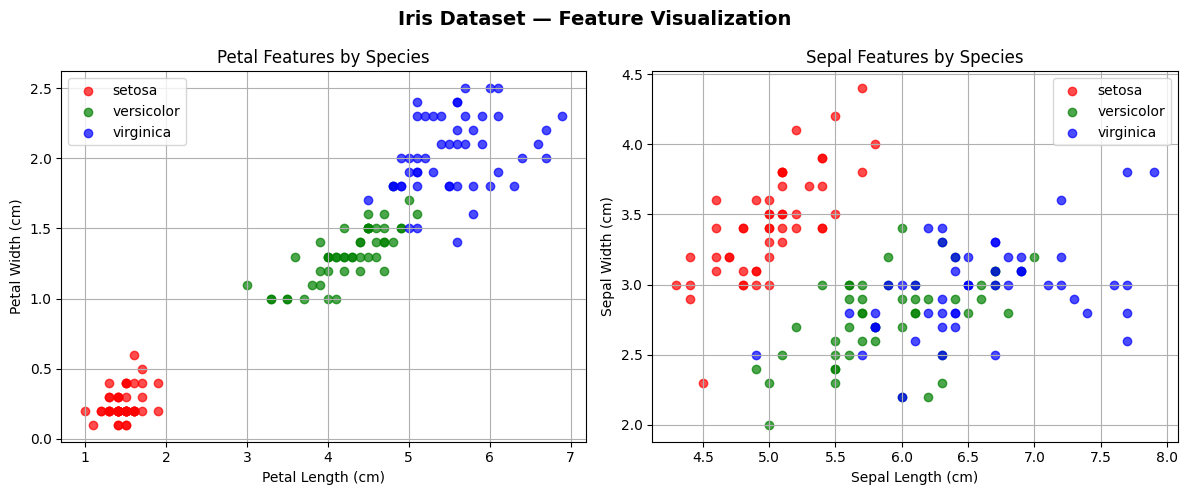

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Petal length vs Petal width (most separable features)
colors = ['red', 'green', 'blue']
for i, name in enumerate(iris.target_names):
    mask = y == i
    axes[0].scatter(X[mask, 2], X[mask, 3], color=colors[i], label=name, alpha=0.7)
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')
axes[0].set_title('Petal Features by Species')
axes[0].legend()
axes[0].grid(True)

# Sepal length vs Sepal width
for i, name in enumerate(iris.target_names):
    mask = y == i
    axes[1].scatter(X[mask, 0], X[mask, 1], color=colors[i], label=name, alpha=0.7)
axes[1].set_xlabel('Sepal Length (cm)')
axes[1].set_ylabel('Sepal Width (cm)')
axes[1].set_title('Sepal Features by Species')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Iris Dataset — Feature Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()